# Heart Disease EDA & Data Cleaning
This notebook performs data acquisition, cleaning, EDA, and saves a processed dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 

#Heart Disease Dataframe (Reading features and targets together, with column names)
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)
df.columns = columns
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
# variable information 
heart_disease.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [5]:
# Checking Metadata
for k,v in heart_disease.metadata.items():
    print(k,v)


uci_id 45
name Heart Disease
repository_url https://archive.ics.uci.edu/dataset/45/heart+disease
data_url https://archive.ics.uci.edu/static/public/45/data.csv
abstract 4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach
area Health and Medicine
tasks ['Classification']
characteristics ['Multivariate']
num_instances 303
num_features 13
feature_types ['Categorical', 'Integer', 'Real']
demographics ['Age', 'Sex']
target_col ['num']
index_col None
has_missing_values yes
missing_values_symbol NaN
year_of_dataset_creation 1989
last_updated Fri Nov 03 2023
dataset_doi 10.24432/C52P4X
creators ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano']
intro_paper {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M. Pfisterer, J. Schmid, S. Sandhu, K. Guppy, S. Lee, V. Froelicher', 'venue': 'American Journal of Car

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [8]:
# Checking for null values
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [9]:
# Filling null values with median
df.fillna(df.median(), inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Converting target to binary
###  0 - No Heart Disease
###  1 - Possible Heart Disease

In [10]:

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)

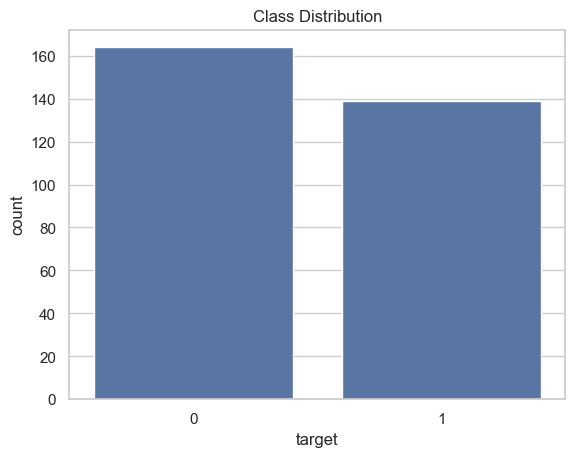

In [12]:
sns.countplot(x='target', data=df)
plt.title('Class Distribution')
plt.savefig('../data/processed/class_distribution.png')
plt.show()

Looks almost balanced

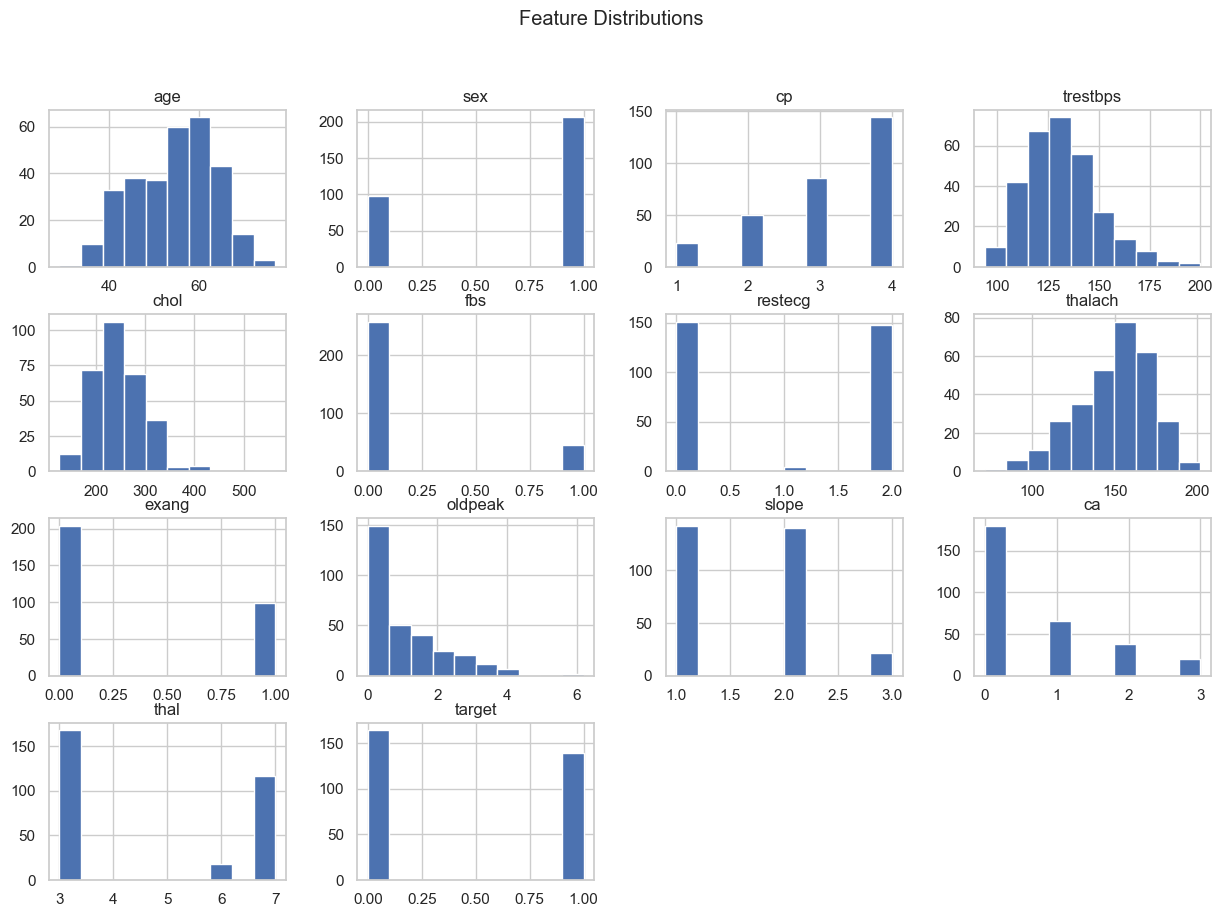

In [13]:
df.hist(figsize=(15,10))
plt.suptitle('Feature Distributions')
plt.savefig('../data/processed/histograms.png')
plt.show()

As per data distributions, mostly all features are categorical and the continuous features are approximately normally distributed.

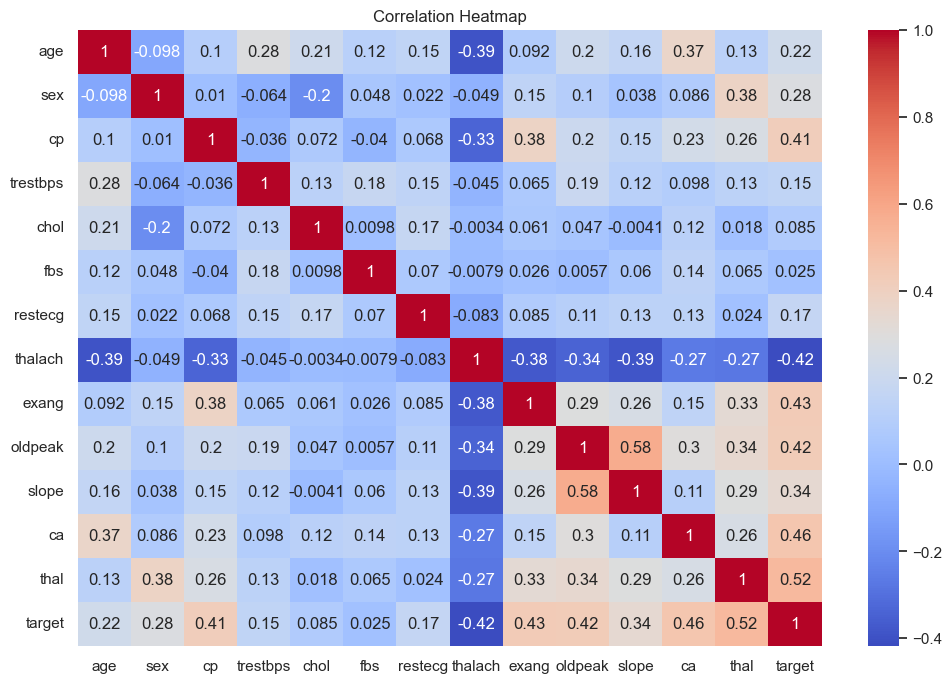

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../data/processed/correlation_heatmap.png')
plt.show()

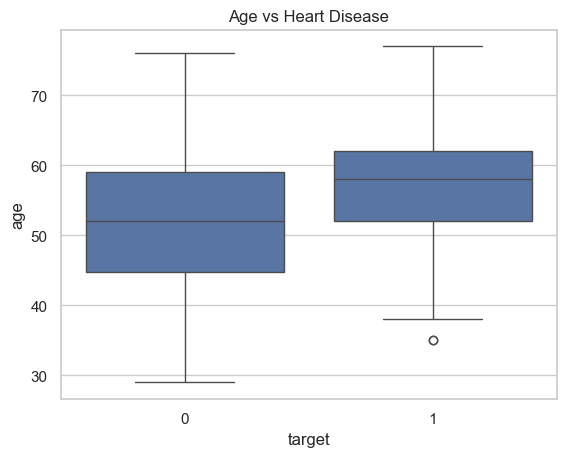

In [15]:
sns.boxplot(x='target', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()

In [16]:
df.to_csv('../data/processed/heart_clean.csv', index=False)
print('Cleaned data saved!')

Cleaned data saved!


### **Activities performed in Data Acquisition and EDA phase**

### Data cleaned and saved
### Missing values replaced by medians
### Target field encoded as binary (0 or 1)
### Analysed data using visualizations